# Figure 3(B) — Distribution of backbone quality scores (suiteness)

Backbone-suiteness distribution by experimental method.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
def _resolution(m):
    if not isinstance(m, dict):
        return None
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def load_scores_df():
    """One row per scored structure with scores + joined validation metadata."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    md = json.load(open(data_file("reference/metadata/metadata_cache.json")))
    vm = md["validation_metrics"]
    nt = md["nucleotide_counts"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb) if isinstance(vm.get(pdb), dict) else {}
        rows.append({
            "pdb": pdb,
            "pairs_score": info.get("pairs_score"),
            "backbone_suiteness": info.get("backbone_suiteness"),
            "residues_score": info.get("residues_score"),
            "n_pairs": info.get("n_pairs", 0),
            "n_residues_scored": info.get("n_residues_scored", 0),
            "method": m.get("Experimental_method"),
            "resolution": _resolution(m),
            "clash": m.get("clashscore"),
            "n_nucleotides": nt.get(pdb),
        })
    return pd.DataFrame(rows)

In [3]:
df = load_scores_df()

saved figures/figure3_B_backbone_score_distribution.png


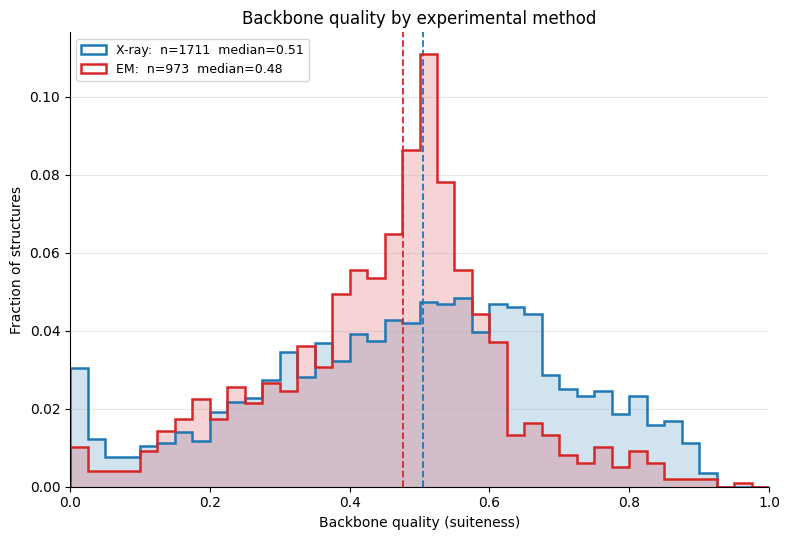

In [4]:
sub = df[df['n_residues_scored'] > 0]
bins = np.linspace(0, 1, 41)
fig, ax = plt.subplots(figsize=(8, 5.5))
for method, color in [('X-ray', 'tab:blue'), ('EM', 'tab:red')]:
    vals = sub.loc[sub['method'] == method, 'backbone_suiteness'].dropna()
    if vals.empty: continue
    w = np.ones(len(vals)) / len(vals)
    ax.hist(vals, bins=bins, weights=w, histtype='stepfilled', color=color, alpha=0.20)
    ax.hist(vals, bins=bins, weights=w, histtype='step', color=color, linewidth=1.8,
            label=f'{method}:  n={len(vals)}  median={vals.median():.2f}')
    ax.axvline(vals.median(), color=color, linestyle='--', linewidth=1.3)
ax.set_xlabel('Backbone quality (suiteness)'); ax.set_ylabel('Fraction of structures')
ax.set_xlim(0, 1); ax.set_title('Backbone quality by experimental method')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3, axis='y')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); print('saved', savefig(fig, 'figure3_B_backbone_score_distribution.png')); plt.show()